# Retrieval lab 
Run Setup first, then each numbered step in order. 

This version separates **one document**,**one embedding**, **all embeddings**, and **database insertion** so you can inspect every stage. Chroma replaces the original pgvector choice in step 06.

Each step explains its purpose, code, and visual output. No output is invented when an operation
is disabled. Saved Chroma embeddings and review flags are reused. The text/model keyed disk cache
lets embedding generation and insertion remain separate without losing completed API batches.

### Setup and controls
`QUERY` is text; `query_vector` is generated in step 09. `CONDITION` controls the exact filter in step 10.
`ALLOW_EMBEDDING_API=True` permits new OpenAI embedding requests in steps 04, 07, 09, and 11.
`INSERT_MISSING=True` permits local database writes in step 08. Embedding API calls are currently enabled; insertion is off.
After editing a setting, **rerun this cell**, then the relevant step. API requests incur usage charges;
reading existing embeddings or searching Chroma locally does not call OpenAI.

In [40]:
from pathlib import Path
import sys, time
from html import escape
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import chromadb

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "pyproject.toml").exists() and (p / "data/raw/drug.csv").exists()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook from the Drug_Assist project.")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
from drug_assist.data import build_documents, validate_clean_data, DOCUMENT_FIELDS
from drug_assist.retrieval import (
    EMBEDDING_MODEL, EMBEDDING_DIMENSIONS, COLLECTION_NAME,
    database_path, openai_client, pending_documents, search, flag_for_review,
)
from drug_assist.cache import read_embedding, save_embedding, validate_vector

CLEAN_PATH = ROOT / "data/processed/drug_clean.csv"
CACHE_DIR = ROOT / "data/cache/embeddings"
ALLOW_EMBEDDING_API = True
INSERT_MISSING = False
QUERY = "medicines for depression"
CONDITION = "depression"
TOP_K = 5
BATCH_SIZE = 100
if TOP_K < 1 or BATCH_SIZE < 1:
    raise ValueError("TOP_K and BATCH_SIZE must be positive.")

def status(message):
    display(HTML('<div style="padding:12px;border-left:4px solid #2563eb;background:#eff6ff;color:#172554">'
                 + escape(str(message)) + '</div>'))

def table(rows):
    display(pd.DataFrame(rows))

def flow(*labels):
    boxes = ['<span style="padding:9px;border:1px solid #94a3b8;border-radius:6px">'
             + escape(label) + '</span>' for label in labels]
    display(HTML('<div style="display:flex;gap:10px;align-items:center;flex-wrap:wrap;margin:12px 0">'
                 + '<span>→</span>'.join(boxes) + '</div>'))

pd.set_option("display.max_colwidth", 120)
table([{"Setting": "Python", "Value": sys.executable},
       {"Setting": "Embedding model", "Value": EMBEDDING_MODEL},
       {"Setting": "Allow new API requests", "Value": ALLOW_EMBEDDING_API},
       {"Setting": "Insert missing records", "Value": INSERT_MISSING}])
flow("01–03: one document", "04–05: one vector", "06–08: database", "09–11: retrieval evaluation")

,Setting,Value
0,Python,c:\Users\suvra_nw8ieuf\AppData\Local\uv-envs\Drug_Assist\Scripts\python.exe
1,Embedding model,text-embedding-3-small
2,Allow new API requests,True
3,Insert missing records,False


## 01. Decide what one searchable document represents

**Purpose:** choose the unit of retrieval. A cleaned dataset row can differ in ratings while repeating
another row's description. One document here is one unique **Condition + Drug + Information** combination.
Different descriptions for a drug remain separate. Ratings stay in the cleaned CSV because we have
not defined how to aggregate them across repeated descriptions.

**Code:** load the cleaned CSV, validate it, and preserve the original deduplication order.
**Output:** a table and bar chart comparing cleaned rows and searchable documents: currently 1,753 and 624.

No API request or database access happens in this step.

,Stage,Count
0,Cleaned rows,1753
1,Searchable documents,624


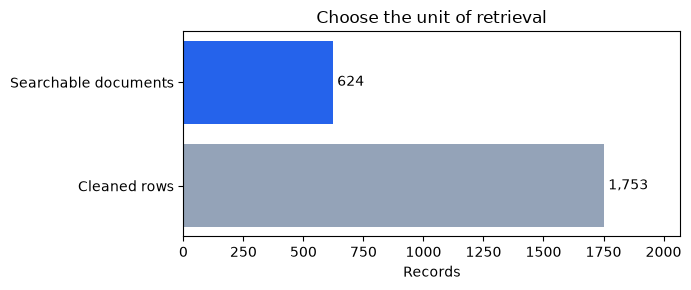

In [53]:
if not CLEAN_PATH.exists():
    raise FileNotFoundError("Run 01_data_ingestion.ipynb first.")
df_clean = pd.read_csv(CLEAN_PATH, dtype={"Reviews": "Int64"})
validate_clean_data(df_clean)
df_vector = df_clean.drop_duplicates(subset=DOCUMENT_FIELDS).reset_index(drop=True).copy()
counts = pd.DataFrame({"Stage": ["Cleaned rows", "Searchable documents"], "Count": [len(df_clean), len(df_vector)]})
display(counts)
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(counts["Stage"], counts["Count"], color=["#94a3b8", "#2563eb"])
for i, value in enumerate(counts["Count"]):
    ax.text(value, i, f" {value:,}", va="center")
ax.set(xlim=(0, counts["Count"].max()*1.18), xlabel="Records", title="Choose the unit of retrieval")
plt.tight_layout()
plt.show()
plt.close(fig)

## 02. Build document_text + metadata from one cleaned row

**Purpose:** prepare just one sample before processing the full dataset.
The text is the embedding input; metadata contains fields for display and filtering.
An ID connects the text, vector, and metadata. `embedding=None` means no vector exists yet.
`needs_review=False` means not flagged, not verified as accurate.

**Output:** the original row, combined text, metadata table, and flow diagram.
Inspect the exact text before sending it to OpenAI. No API call occurs here.

In [109]:
row = df_vector.iloc[0]
document = {
    "id": "drug_0",
    "document_text": f"Condition: {row['Condition']}\nDrug: {row['Drug']}\nInformation: {row['Information']}",
    "metadata": {"condition": row["Condition"], "drug": row["Drug"],
                 "information": row["Information"], "needs_review": False},
    "embedding": None,
}
display(row[DOCUMENT_FIELDS].to_frame("Source row"))
flow("One row", "ID + text + metadata", "One searchable document")
display(HTML('<pre style="white-space:pre-wrap">'+escape(document["document_text"])+ '</pre>'))
table([{"Metadata field": key, "Value": value} for key, value in document["metadata"].items()])

,Source row
Condition,Acute Bacterial Sinusitis
Drug,Levofloxacin
Information,Levofloxacin is used to treat a variety of bacterial infections. This is a generic drug. The average cash price for ...


,Metadata field,Value
0,condition,Acute Bacterial Sinusitis
1,drug,Levofloxacin
2,information,Levofloxacin is used to treat a variety of bacterial infections. This is a generic drug. The average cash price for ...
3,needs_review,False


## 03. Define the schema for that document

**Purpose:** check types and required fields before spending API usage or storing malformed records.
This is a Python document schema, not a SQL table. The vector will later contain 1,536 finite numbers.

**Output:** field definitions and PASS/FAIL checks. Failed checks stop execution.
These checks validate structure; they do not verify the factual content of drug descriptions.

In [110]:
table([{"Field": "id", "Type": "str", "Purpose": "Identify the record"},
       {"Field": "document_text", "Type": "str", "Purpose": "Embedding input"},
       {"Field": "metadata", "Type": "dict", "Purpose": "Display and filter fields"},
       {"Field": "embedding", "Type": "None → list[float]", "Purpose": "Numeric representation"}])
checks = {
    "Nonempty ID": isinstance(document["id"], str) and bool(document["id"].strip()),
    "Nonempty text": isinstance(document["document_text"], str) and bool(document["document_text"].strip()),
    "Required metadata": all(isinstance(document["metadata"].get(k), str) and bool(document["metadata"][k].strip())
                             for k in ("condition", "drug", "information")),
    "Boolean review flag": isinstance(document["metadata"].get("needs_review"), bool),
}
table([{"Check": key, "Result": "PASS" if value else "FAIL"} for key, value in checks.items()])
if not all(checks.values()):
    raise ValueError("Fix schema failures before continuing.")

,Field,Type,Purpose
0,id,str,Identify the record
1,document_text,str,Embedding input
2,metadata,dict,Display and filter fields
3,embedding,None → list[float],Numeric representation


,Check,Result
0,Nonempty ID,PASS
1,Nonempty text,PASS
2,Required metadata,PASS
3,Boolean review flag,PASS


## 04. Generate ONE embedding

**Purpose:** prove that one sample can be converted into a vector. Embeddings are numbers, not generated answers.
`api_client.embeddings.create(...)` is the exact OpenAI request. It sends the sample document text.
The result is cached by exact text, model, and dimension count so repeated runs can reuse it.

Chroma has not been opened yet, preserving your original order. The first sample may require one request
even if your existing Chroma database already contains it. Enable `ALLOW_EMBEDDING_API` in Setup to allow this.
**Output:** cache/API origin and elapsed time. A disabled request without a cache reports Not generated.

In [111]:
started = time.perf_counter()
sample_vector = read_embedding(CACHE_DIR, document["document_text"], EMBEDDING_MODEL, EMBEDDING_DIMENSIONS)
origin = "Disk cache"
if sample_vector is None and ALLOW_EMBEDDING_API:
    status("Sending ONE document to OpenAI...")
    api_client = openai_client(ROOT)
    response = api_client.embeddings.create(  # OPENAI API CALL
        model=EMBEDDING_MODEL, input=[document["document_text"]],
    )
    sample_vector = response.data[0].embedding
    save_embedding(CACHE_DIR, document["document_text"], EMBEDDING_MODEL, EMBEDDING_DIMENSIONS, sample_vector)
    origin = "OpenAI API"
document["embedding"] = sample_vector
if sample_vector is None:
    status("Enable ALLOW_EMBEDDING_API in Setup, rerun Setup, then rerun this step to generate the sample.")
table([{"Document": document["id"], "Source": origin if sample_vector is not None else "Not generated",
        "Model": EMBEDDING_MODEL, "Elapsed seconds": round(time.perf_counter()-started, 2)}])

,Document,Source,Model,Elapsed seconds
0,drug_0,Disk cache,text-embedding-3-small,0.0


## 05. Inspect its dimensionality

**Purpose:** check the length of the vector before choosing its storage. Our model produces 1,536 coordinates.
All document and query vectors must use the same model and dimensions. Matching dimensions alone do not
make two different models compatible.

**Output:** a dimension check, the first ten numbers, and a plot of the first 65 coordinates.
Individual coordinates have no simple label such as "drug" or "condition". This plot illustrates numbers,
not clinical quality. It reads the sample vector without making another request.

,Dimensions,Expected,Check
0,1536,1536,PASS


,Position,Value
0,0,-0.057739
1,1,-0.041321
2,2,0.004211
3,3,0.037048
4,4,-0.017395
5,5,0.007572
6,6,-0.027267
7,7,0.026245
8,8,-0.035431
9,9,0.005142


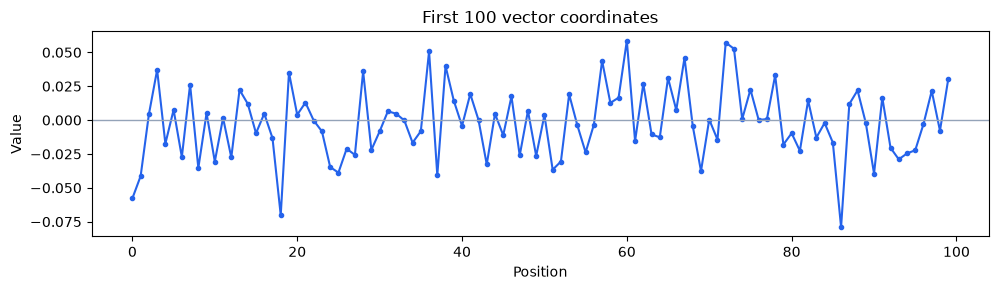

In [148]:
if document["embedding"] is None:
    status("Complete step 04 to see its vector and dimensionality.")
else:
    vector = np.asarray(document["embedding"], dtype=float)
    validate_vector(vector, EMBEDDING_DIMENSIONS)
    table([{"Dimensions": len(vector), "Expected": EMBEDDING_DIMENSIONS, "Check": "PASS"}])
    display(pd.DataFrame({"Position": np.arange(10), "Value": vector[:10]}))
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(np.arange(100), vector[:100], marker=".", color="#2563eb")
    ax.axhline(0, color="#94a3b8", linewidth=1)
    ax.set(title="First 100 vector coordinates", xlabel="Position", ylabel="Value")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## 06. Choose/create the database - local ChromaDB

**Purpose:** now open persistent storage. Chroma replaces pgvector in your original plan.
`PersistentClient` stores files outside OneDrive. The collection is reopened if it already exists.
`embedding_function=None` means we supply vectors ourselves, using the same model consistently.
Cosine distance measures vector direction; smaller means closer. Chroma learns dimensions on first insertion.

**Output:** collection name, path, count, and expected model. This neither inserts documents nor calls OpenAI.

In [156]:
db_path = database_path()
chroma_client = chromadb.PersistentClient(path=str(db_path))
collection = chroma_client.get_or_create_collection(
    name=COLLECTION_NAME, embedding_function=None, configuration={"hnsw": {"space": "cosine"}},
)
table([{"Property": "Folder", "Value": str(db_path)},
       {"Property": "Collection", "Value": collection.name},
       {"Property": "Stored records", "Value": collection.count()},
       {"Property": "Our embedding model", "Value": EMBEDDING_MODEL},
       {"Property": "Required dimensions", "Value": EMBEDDING_DIMENSIONS}])
flow("Notebook", "PersistentClient", "Local Chroma files")

,Property,Value
0,Folder,C:\Users\suvra_nw8ieuf\AppData\Local\Drug_Assist\chroma
1,Collection,drug_documents
2,Stored records,624
3,Our embedding model,text-embedding-3-small
4,Required dimensions,1536


## 07. Embed all documents

**Purpose:** prepare vectors for the full document list without inserting records yet.
First check whether saved IDs still map to the same text. If the source was reordered and IDs collide,
stop and use a new collection instead of overwriting records.

Reuse Chroma vectors first, then cached vectors. Only missing text is sent to OpenAI in batches of 100.
Save every returned vector to the disk cache immediately. The sample from step 04 is reused.
**Output:** vector origins, ready/missing counts, and a bar chart. A complete existing collection needs
no new document-embedding requests. Disk caching makes this step restartable before step 08.

,Source,Vectors
0,Chroma,624
1,Disk cache,0
2,OpenAI API,0


,Documents,Ready,Missing
0,624,624,0


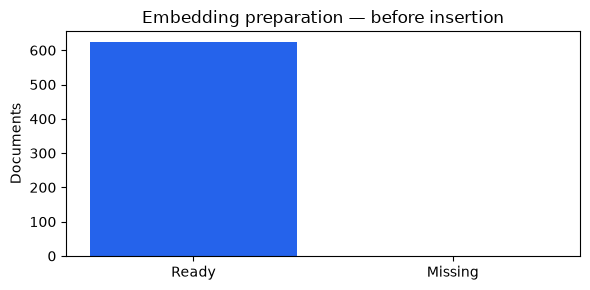

In [163]:
documents = build_documents(df_clean)
pending_documents(collection, documents)
saved = collection.get(include=["embeddings"])
saved_vectors = dict(zip(saved["ids"], saved["embeddings"])) if saved["ids"] else {}
origins = {"Chroma": 0, "Disk cache": 0, "OpenAI API": 0}
for doc in documents:
    vector = saved_vectors.get(doc["id"])
    if vector is not None:
        vector = [float(x) for x in vector]
        validate_vector(vector, EMBEDDING_DIMENSIONS)
        origins["Chroma"] += 1
    else:
        vector = read_embedding(CACHE_DIR, doc["document_text"], EMBEDDING_MODEL, EMBEDDING_DIMENSIONS)
        if vector is not None:
            origins["Disk cache"] += 1
    doc["embedding"] = vector
missing_vectors = [doc for doc in documents if doc["embedding"] is None]
if missing_vectors and ALLOW_EMBEDDING_API:
    api_client = openai_client(ROOT)
    for start in range(0, len(missing_vectors), BATCH_SIZE):
        batch = missing_vectors[start:start+BATCH_SIZE]
        print(f"Embedding batch {start//BATCH_SIZE + 1}: {len(batch)} documents...", flush=True)
        response = api_client.embeddings.create(  # OPENAI API CALL
            model=EMBEDDING_MODEL, input=[doc["document_text"] for doc in batch],
        )
        if sorted(item.index for item in response.data) != list(range(len(batch))):
            raise ValueError("Embedding response indices do not match this batch.")
        for item in response.data:
            doc = batch[item.index]
            save_embedding(CACHE_DIR, doc["document_text"], EMBEDDING_MODEL, EMBEDDING_DIMENSIONS, item.embedding)
            doc["embedding"] = item.embedding
            origins["OpenAI API"] += 1
ready = sum(doc["embedding"] is not None for doc in documents)
table([{"Source": key, "Vectors": value} for key, value in origins.items()])
table([{"Documents": len(documents), "Ready": ready, "Missing": len(documents)-ready}])
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(["Ready", "Missing"], [ready, len(documents)-ready], color=["#2563eb", "#f59e0b"])
ax.set(ylabel="Documents", title="Embedding preparation — before insertion")
plt.tight_layout()
plt.show()
plt.close(fig)
if ready < len(documents):
    status("Enable ALLOW_EMBEDDING_API in Setup and rerun this step for the missing vectors.")

## 08. Insert them

**Purpose:** store prepared vectors with IDs, text, and metadata. This is separate from generation.
Set `INSERT_MISSING=True` in Setup, rerun Setup, then this step. `collection.add` writes locally;
it is not an OpenAI request. Existing records and review flags are preserved because only new IDs are added.
All missing records must have vectors before insertion begins.

**Output:** before/after counts and a saved sample. If all records exist, no insertion is needed.
After restarting a kernel, rerun step 07 to recover vectors from disk cache or Chroma before inserting.

In [169]:
missing_records = pending_documents(collection, documents)
before = collection.count()
if missing_records and INSERT_MISSING:
    if any(doc["embedding"] is None for doc in missing_records):
        raise ValueError("Complete step 07: a missing record has no vector.")
    for start in range(0, len(missing_records), BATCH_SIZE):
        batch = missing_records[start:start+BATCH_SIZE]
        collection.add(ids=[doc["id"] for doc in batch],
                       documents=[doc["document_text"] for doc in batch],
                       metadatas=[doc["metadata"] for doc in batch],
                       embeddings=[doc["embedding"] for doc in batch])
    status("Inserted missing records; retained existing records and flags.")
elif missing_records:
    status("Insertion is off. Enable INSERT_MISSING in Setup, rerun Setup, then this step.")
else:
    status("All records already exist; no insertion needed.")
table([{"Before": before, "After": collection.count(), "Inserted": collection.count()-before,
        "Still missing": len(pending_documents(collection, documents))}])
preview = collection.get(ids=[document["id"]], include=["documents", "metadatas"])
table([{"ID": i, "Text": text, "Metadata": meta}
       for i, text, meta in zip(preview["ids"], preview["documents"], preview["metadatas"])])

,Before,After,Inserted,Still missing
0,624,624,0,0


,ID,Text,Metadata
0,drug_0,Condition: Acute Bacterial Sinusitis\nDrug: Levofloxacin\nInformation: Levofloxacin is used to treat a variety of ba...,"{'condition': 'Acute Bacterial Sinusitis', 'information': 'Levofloxacin is used to treat a variety of bacterial infe..."


## 09. Semantic search

**Purpose:** represent the question using the same model as the stored documents, then find nearest vectors.
`QUERY` is text. `query_vector` is a list of numbers. Load its cache or generate it with the marked API call.
`search()` then runs locally, excluding flagged IDs and passing `query_embeddings=[query_vector]` to Chroma.
The brackets mean a batch containing one query. Unflagged records are searchable, not necessarily verified.

**Output:** a flow diagram, separate embedding/search timings, ranked result table, and distance chart.
Smaller cosine distance means closer text similarity; it is not a confidence percentage or clinical score.
Changing QUERY requires rerunning this step. Identical cached questions do not incur new embedding requests.

,Query,Embedding seconds,Search seconds,Matches
0,medicines for depression,0.003,0.058,5


,id,information,drug,condition,distance,document_text
0,drug_177,This medication is used to treat mental/mood problems such as depression. This is a generic drug. You can buy amitri...,Amitriptyline,depression,0.484771,Condition: depression\nDrug: Amitriptyline\nInformation: This medication is used to treat mental/mood problems such ...
1,drug_181,This medication is used to treat depression. This is a generic drug. You can buy imipramine hcl at the discounted pr...,Imipramine Hcl,depression,0.523238,Condition: depression\nDrug: Imipramine Hcl\nInformation: This medication is used to treat depression. This is a gen...
2,drug_178,This medication is used to treat mental/mood problems such as depression. This is a generic drug. You can buy nortri...,Nortriptyline,depression,0.523972,Condition: depression\nDrug: Nortriptyline\nInformation: This medication is used to treat mental/mood problems such ...
3,drug_187,This medication is used to treat various types of depression and related anxiety. This is a generic drug. The averag...,Maprotiline,depression,0.533866,Condition: depression\nDrug: Maprotiline\nInformation: This medication is used to treat various types of depression ...
4,drug_294,This medication is used to treat mental/mood problems such as depression. This is a generic drug. You can buy amitri...,Amitriptyline,fibromyalgia,0.533907,Condition: fibromyalgia\nDrug: Amitriptyline\nInformation: This medication is used to treat mental/mood problems suc...


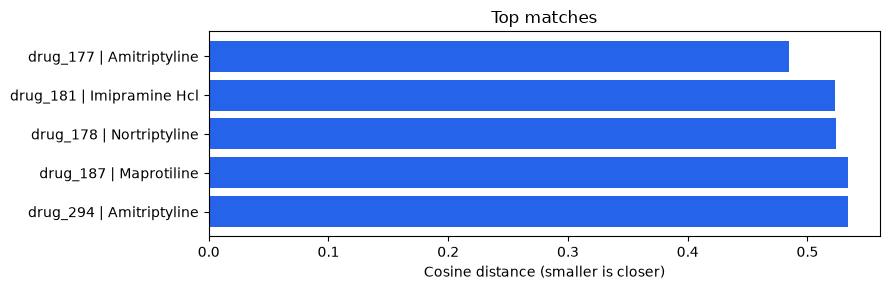

In [174]:
flow("Query text", "Query embedding", "Local Chroma search", "Top matches")
query_text_used = QUERY
started = time.perf_counter()
query_vector = read_embedding(CACHE_DIR, QUERY, EMBEDDING_MODEL, EMBEDDING_DIMENSIONS)
results = []
if query_vector is None and ALLOW_EMBEDDING_API:
    status("Embedding the query with OpenAI...")
    api_client = openai_client(ROOT)
    response = api_client.embeddings.create(model=EMBEDDING_MODEL, input=[QUERY])  # OPENAI API CALL
    query_vector = response.data[0].embedding
    save_embedding(CACHE_DIR, QUERY, EMBEDDING_MODEL, EMBEDDING_DIMENSIONS, query_vector)
embedding_seconds = time.perf_counter()-started
if query_vector is None:
    status("No cached query vector. Enable ALLOW_EMBEDDING_API in Setup and rerun this step.")
elif collection.count() == 0:
    status("Chroma is empty. Complete step 08 before searching.")
else:
    started = time.perf_counter()
    results = search(collection, query_vector, k=TOP_K)
    table([{"Query": QUERY, "Embedding seconds": round(embedding_seconds, 3),
            "Search seconds": round(time.perf_counter()-started, 3), "Matches": len(results)}])
    display(pd.DataFrame(results))
    if results:
        fig, ax = plt.subplots(figsize=(9, 3))
        ax.barh([x["id"]+" | "+x["drug"] for x in results], [x["distance"] for x in results], color="#2563eb")
        ax.invert_yaxis()
        ax.set(xlabel="Cosine distance (smaller is closer)", title="Top matches")
        plt.tight_layout()
        plt.show()
        plt.close(fig)

## 10. Metadata filtering

**Purpose:** enforce an exact condition label before ranking eligible results by similarity.
For example, a depression filter restricts results to records labeled depression even if the query asks
about something else. Review flags are also excluded.

Reuse the query vector from step 09, so there is no API call here. Changing only CONDITION needs this step
rerun; changing QUERY needs step 09 first. **Output:** filtered results and a count comparison.
Evaluation in step 11 does not use the expected-condition filter, which would make its test circular.

In [178]:
filtered_results = []
if query_vector is None:
    status("Complete step 09 first to obtain a query vector.")
elif QUERY != query_text_used:
    raise ValueError("QUERY changed. Rerun step 09 before reusing its vector.")
else:
    filtered_results = search(collection, query_vector, k=TOP_K, condition=CONDITION)
    table([{"Query": QUERY, "Filter": CONDITION, "Without condition filter": len(results),
            "With condition filter": len(filtered_results)}])
    display(pd.DataFrame(filtered_results))

,Query,Filter,Without condition filter,With condition filter
0,medicines for depression,depression,5,5


,id,drug,condition,information,distance,document_text
0,drug_177,Amitriptyline,depression,This medication is used to treat mental/mood problems such as depression. This is a generic drug. You can buy amitri...,0.484771,Condition: depression\nDrug: Amitriptyline\nInformation: This medication is used to treat mental/mood problems such ...
1,drug_181,Imipramine Hcl,depression,This medication is used to treat depression. This is a generic drug. You can buy imipramine hcl at the discounted pr...,0.523238,Condition: depression\nDrug: Imipramine Hcl\nInformation: This medication is used to treat depression. This is a gen...
2,drug_178,Nortriptyline,depression,This medication is used to treat mental/mood problems such as depression. This is a generic drug. You can buy nortri...,0.523972,Condition: depression\nDrug: Nortriptyline\nInformation: This medication is used to treat mental/mood problems such ...
3,drug_187,Maprotiline,depression,This medication is used to treat various types of depression and related anxiety. This is a generic drug. The averag...,0.533866,Condition: depression\nDrug: Maprotiline\nInformation: This medication is used to treat various types of depression ...
4,drug_184,Desipramine,depression,"Desipramine is used to treat depression. This is a generic drug. The average cash price for 30 Tablet(s), 25mg each ...",0.534570,Condition: depression\nDrug: Desipramine\nInformation: Desipramine is used to treat depression. This is a generic dr...


## 11. Retrieval evaluation

**Purpose:** test multiple questions using expected condition labels. You set those labels, not Chroma.
For acid reflux, the expected label is gastroesophageal reflux disease. The searches do not filter to
that expected condition; they only exclude known review flags.

The raw score is `correct_condition / TOP_K`. **Precision (%)** appears beside it in this same cell's
table, followed by a percentage chart. Three correct labels out of three means 100%; two means 66.7%.
Fewer returned records cannot inflate the score. Cached query vectors are reused; uncached questions
are embedded together when API access is enabled. Missing vectors show Not evaluated, not a false 0%.

This is a condition-match proxy. It does not establish factual accuracy or treatment suitability.
Read the result text and flag mismatches even if the label score is 100%. One can broaden these starter tests before proceeding further.

,query,expected_condition,Status,returned,correct_condition,condition_precision_at_k,Precision (%),retrieved_ids
0,medicines for hypertension,hypertension,Evaluated,5,5,1.0,100.0%,"[drug_543, drug_481, drug_477, drug_513, drug_518]"
1,medicines for depression,depression,Evaluated,5,4,0.8,80.0%,"[drug_177, drug_181, drug_178, drug_187, drug_294]"
2,medicines for acid reflux,gastroesophageal reflux disease,Evaluated,5,5,1.0,100.0%,"[drug_350, drug_335, drug_338, drug_359, drug_328]"


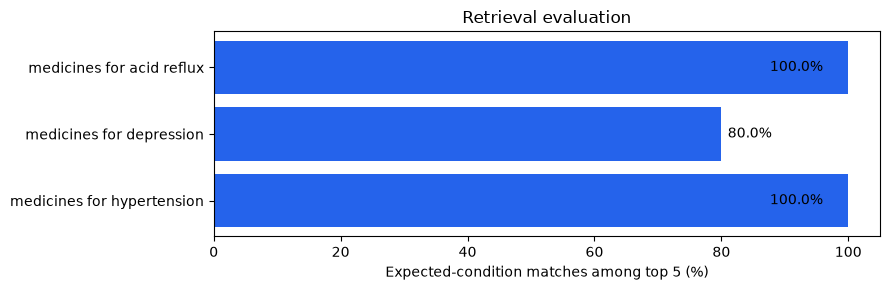

In [181]:
evaluation_cases = [
    {"query": "medicines for hypertension", "expected_condition": "hypertension"},
    {"query": "medicines for depression", "expected_condition": "depression"},
    {"query": "medicines for acid reflux", "expected_condition": "gastroesophageal reflux disease"},
]
evaluation = []
known_conditions = set(df_clean["Condition"].dropna())
for case in evaluation_cases:
    if case["expected_condition"] not in known_conditions:
        raise ValueError(f"Unknown expected condition: {case['expected_condition']}")
evaluation_vectors = {case["query"]: read_embedding(CACHE_DIR, case["query"], EMBEDDING_MODEL, EMBEDDING_DIMENSIONS)
                      for case in evaluation_cases}
uncached = [text for text, vector in evaluation_vectors.items() if vector is None]
if uncached and ALLOW_EMBEDDING_API:
    status(f"Embedding {len(uncached)} uncached evaluation queries...")
    api_client = openai_client(ROOT)
    response = api_client.embeddings.create(model=EMBEDDING_MODEL, input=uncached)  # OPENAI API CALL
    if sorted(item.index for item in response.data) != list(range(len(uncached))):
        raise ValueError("Evaluation response indices do not match the queries.")
    for item in response.data:
        text = uncached[item.index]
        evaluation_vectors[text] = item.embedding
        save_embedding(CACHE_DIR, text, EMBEDDING_MODEL, EMBEDDING_DIMENSIONS, item.embedding)
for case in evaluation_cases:
    vector = evaluation_vectors[case["query"]]
    if vector is None:
        evaluation.append({**case, "Status": "Needs query embedding", "returned": None,
                           "correct_condition": None, "condition_precision_at_k": None, "retrieved_ids": []})
        continue
    matches = search(collection, vector, k=TOP_K)
    correct = sum(item["condition"] == case["expected_condition"] for item in matches)
    evaluation.append({**case, "Status": "Evaluated", "returned": len(matches), "correct_condition": correct,
                       "condition_precision_at_k": correct/TOP_K, "retrieved_ids": [item["id"] for item in matches]})
evaluation_df = pd.DataFrame(evaluation)
evaluation_df.insert(evaluation_df.columns.get_loc("condition_precision_at_k")+1, "Precision (%)",
    evaluation_df["condition_precision_at_k"].map(lambda x: "Not evaluated" if pd.isna(x) else f"{x:.1%}"))
display(evaluation_df)
evaluated = evaluation_df.dropna(subset=["condition_precision_at_k"])
if not evaluated.empty:
    fig, ax = plt.subplots(figsize=(9, 3))
    percentages = evaluated["condition_precision_at_k"]*100
    ax.barh(evaluated["query"], percentages, color="#2563eb")
    for i, value in enumerate(percentages):
        ax.text(min(value+1, 96), i, f"{value:.1f}%", va="center", ha="right" if value>95 else "left")
    ax.set(xlim=(0, 105), xlabel=f"Expected-condition matches among top {TOP_K} (%)", title="Retrieval evaluation")
    plt.tight_layout()
    plt.show()
    plt.close(fig)
else:
    status("Enable ALLOW_EMBEDDING_API in Setup and rerun step 11 to evaluate the uncached queries.")

### Optional review loop within step 11
Copy a specific retrieved ID below and inspect its text before flagging. A result's rank can change;
never use the position as its identity. Set `APPLY_REVIEW_FLAG=True` only to save the flag locally.
Then rerun steps 09–11. This does not correct the source description or call OpenAI.

In [183]:
REVIEW_ID = "drug_177"
REVIEW_REASON = ""
APPLY_REVIEW_FLAG = False
if REVIEW_ID:
    record = collection.get(ids=[REVIEW_ID], include=["documents", "metadatas"])
    table([{"ID": i, "Text": text, "Metadata": meta}
           for i, text, meta in zip(record["ids"], record["documents"], record["metadatas"])])
if APPLY_REVIEW_FLAG:
    flag_for_review(collection, REVIEW_ID, REVIEW_REASON)
    status("Flag saved. Rerun steps 09–11 to refresh results.")
flagged = collection.get(where={"needs_review": True}, include=["metadatas"])
table([{"Flagged records": len(flagged["ids"]), "Flagged IDs": flagged["ids"]}])

,ID,Text,Metadata
0,drug_177,Condition: depression\nDrug: Amitriptyline\nInformation: This medication is used to treat mental/mood problems such ...,{'information': 'This medication is used to treat mental/mood problems such as depression. This is a generic drug. Y...


,Flagged records,Flagged IDs
0,0,[]


### To be continued after having feedback from Ofer.
This notebook does not use LangChain or generate LLM answers.

References: [OpenAI embeddings](https://developers.openai.com/api/docs/guides/embeddings),
[Chroma collections](https://docs.trychroma.com/docs/collections/manage-collections),
[Chroma query and get](https://docs.trychroma.com/docs/querying-collections/query-and-get).